# Deutsch-Josza Algorithm

## Problem: Given a function $f(x): \{0,1\}^n\rightarrow\{0,1\}$, we want to determine if it is constant or balanced by performing a single measurement.

We will implement this quantum algorithm on the $n=1$ case (one bit function)

All and only balanced functions on one bit are the identity $f(x)=x$ and the NOT logic operator $f(x)=\neg{x}$

All and only constant functions on one bit are $f(x)=0$ and $f(x)=1$

## Classical solution

### On one bit ($n=1$), we need to evaluate both $f(0)$ and $f(1)$ to determine whether it is constant or balanced

In general, with $n>1$, we need $2^{n-1} + 1$ evaluations (half plus one of the total cases) to be 100% sure that $f(x)$ is constant.

With the Deutsch-Josza quantum algorithm, we only need one measurement to solve the problem, independently of the number of input bits $n$ of $f(x)$.

## Quantum Oracle

To implement $f(x)$ on a quantum computer we need a Quantum Oracle:

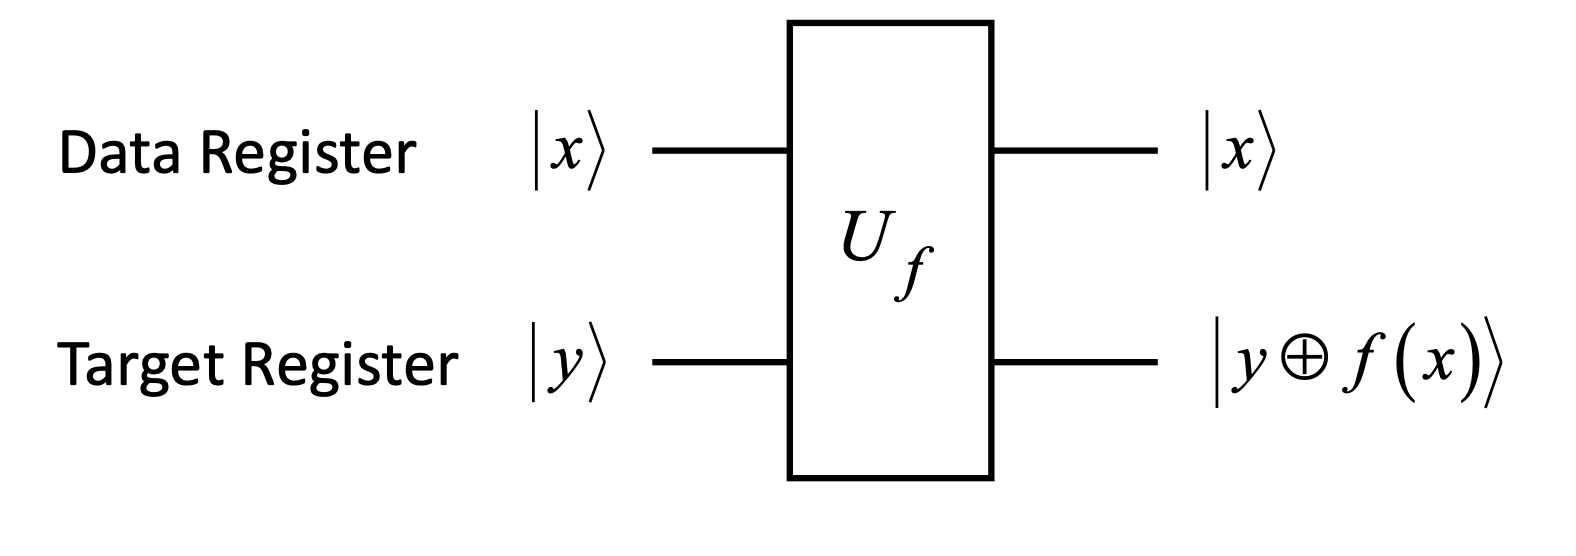

### Question: Why do we need a quantum oracle? Cannot we simply define a quantum gate that implements $f(x)$?

Implementing the quantum oracle for single bit $f(x)$:

In [1]:
from qiskit import QuantumRegister, ClassicalRegister
from qiskit import QuantumCircuit

In [2]:
def get_oracle(func_name):
    """
    Get the oracle for a given function specified by name.
    
    Parameters
    ------------
    
    func_name: str
        The name of the 1-bit function. can be either "I", "NOT", "0", "1".
    
    Returns
    -----------
    Gate
    """
    
    circ = QuantumCircuit(2)
    
    if func_name == "I":
        circ.cx(0,1)
    elif func_name == "NOT":
        circ.cx(0,1, ctrl_state="0")
    elif func_name == "0":
        # do nothing
        pass
    elif func_name == "1":
        circ.x(1)
    else:
        raise ValueError("func_name not valid")
    
    return circ.to_gate(label="U_"+func_name)
        
    

## Implement Deutsch algorithm

In [13]:
# This will be the input to the algorithm
func_name = "I"
oracle = get_oracle(func_name)

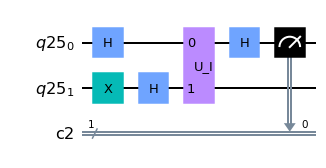

In [14]:
qr = QuantumRegister(2)
cr = ClassicalRegister(1)

dj_circ = QuantumCircuit(qr, cr)

dj_circ.x(qr[1])

dj_circ.h(qr[0])
dj_circ.h(qr[1])

dj_circ.append(oracle, qr[:])
dj_circ.h(qr[0])

dj_circ.measure(qr[0], cr[0])

dj_circ.draw(output="mpl")

## Run Deutsch algorithm (Aer)

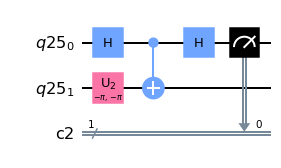

In [15]:
from qiskit import Aer
from qiskit.compiler import transpile

# We get a qasm simulator as backend from Aer
backend = Aer.get_backend('qasm_simulator')

from qiskit.compiler import transpile
tr_circ = transpile(dj_circ, backend, optimization_level=1)

tr_circ.draw(output="mpl")

In [16]:
# We define our job
job = backend.run(tr_circ, shots=2048)

# We execute and collect the results:
result = job.result()

# We collect the measurements in a dictionary
counts = result.get_counts()

print(counts)

{'1': 2048}


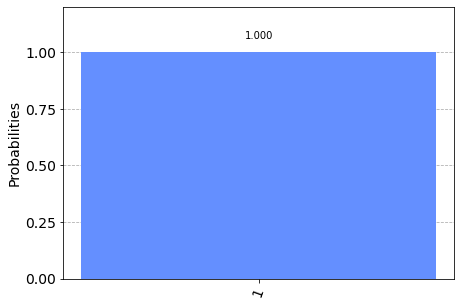

In [17]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

## Run Deutsch algorithm (IBMQ)

Finally, we are ready to test our first quantum program on a real quantum device.

First of all, we need to connect the IBM-Q account with Qiskit. To do so, put the following line of code:

In [18]:
from qiskit import IBMQ

#IBMQ.save_account("Put_here_the_IBMQ_Token_I_Told_You_In_The_First_Lab")

The `save_account(token)` method stores your credentials on disk, so you never have to call this method again on this machine until you call the `delete_account()` function. See the official tutorial [at IBM-Q website](https://quantum-computing.ibm.com/lab/docs/iql/manage/account/ibmq)

In [ ]:
# load your IBMQ account (already saved on the machine)
IBMQ.load_account()

# A function to get the least busy backend from a given list of backends
from qiskit.providers.ibmq import least_busy

provider = IBMQ.get_provider(hub='ibm-q')
backend = least_busy(provider.backends(filters=lambda x: x.configuration().n_qubits >= 2 and
                                   not x.configuration().simulator and x.status().operational==True))
print("least busy backend: ", backend)

In [ ]:
# Run our circuit on the least busy backend. Monitor the execution of the job in the queue
from qiskit.tools.monitor import job_monitor

transpiled_dj_circuit = transpile(dj_circ, backend, optimization_level=1)

transpiled_dj_circuit.draw(output="mpl")

In [ ]:
job = backend.run(transpiled_dj_circuit, shots=2048)
job_monitor(job, interval=2)

In [ ]:
# Get the results of the computation
results = job.result()
answer = results.get_counts()

plot_histogram(answer)